In [1]:
# Fusion_PhD-38e9.27: GFTM B_par/A_par vs GS2 before and after the pyro GFTM reader fix
# (pyro feature/claude/gftm-tglf-bpar-normalisation). Same cases and cuts as gftm_bpar_ratio.ipynb (38e9.26).
# "old" = the original GFTM pyro objects; "new" = the same GFTM output re-read with the fixed reader
# ($GYRO_DATA_OUTPUT/GFTM/Runs/pyro_bpar_normalisation, Fusion_PhD results/pyro_bpar_normalisation/rebuild_gftm.py).
from pathlib import Path
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
from scipy.integrate import trapezoid
from dotenv import load_dotenv
import pyrokinetics
from pyrokinetics import PyroScan
from pyrokinetics.pyroscan import PyroScanGKOutput
from general_analysis import mode_classification as mc

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file() and (p / "notebooks").is_dir())
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
load_dotenv(ROOT / "local.env", override=True)
warnings.filterwarnings("ignore")
print("pyrokinetics", pyrokinetics.__file__)

data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
fixed_root = data_root / "GFTM" / "Runs" / "pyro_bpar_normalisation"
plot_dir = ROOT / "Plots" / "pyro_bpar_normalisation"
plot_dir.mkdir(parents=True, exist_ok=True)
hypercubes, beta_scans = ["SPR-045", "M1"], ["R3", "R4", "M1_A1_NE"]
databases = hypercubes + beta_scans
widths = {0.4: ("wo_f05_w0p4000", "w0p4"), 0.8: ("wo_f05_w0p8000", "w0p8")}
gs2_tol, same_gamma, same_overlap = 0.1, 1.5, 0.85     # as 38e9.26
fs_title, fs_label, fs_tick, fs_legend = 16, 16, 14, 12


pyrokinetics /pitagora_work/FUPB2_QLTURB/fwatts/pyro_bpar_38e927/src/pyrokinetics/__init__.py


In [2]:
def mag(da):
    return np.asarray(da.pint.dequantify().values)


def dominant(g, ef):
    "argmax gamma over the last (mode) axis"
    g = np.nan_to_num(g, nan=-np.inf)
    i = g.argmax(-1)
    return np.take_along_axis(g, i[..., None], -1)[..., 0], np.take_along_axis(ef, i[..., None, None, None], -1)[..., 0]


def peak_ratio(ef, k):
    "peak|field k| / peak|phi| of (case, field, theta) eigenfunctions"
    a = np.abs(np.nan_to_num(ef))
    return a[:, k].max(-1) / a[:, 0].max(-1)


def phi_overlap(th_s, phi_s, th_g, phi_g):
    "|<phi_GFTM, phi_GS2>| on GS2's theta grid, max over conjugation (as 38e9.26)"
    out = []
    for ps, pg in zip(np.nan_to_num(phi_s), phi_g):
        pg = np.interp(th_s, th_g, pg.real, left=0, right=0) + 1j * np.interp(th_s, th_g, pg.imag, left=0, right=0)
        ip = lambda a, b: abs(trapezoid(np.conj(a) * b, th_s))
        out.append(max(ip(pg, ps), ip(np.conj(pg), ps)) / np.sqrt(ip(pg, pg) * ip(ps, ps)))
    return np.array(out)


def gftm_pair(d_old, d_new, n):
    "dominant (gamma, eigenfunction) of old and new GFTM objects; the reader fix must not move gamma"
    g_old, g_new = (mag(d.growth_rate.transpose(*d.growth_rate.dims[:-1], "mode")).reshape(n, -1) for d in (d_old, d_new))
    assert np.array_equal(np.nan_to_num(g_old, nan=-1), np.nan_to_num(g_new, nan=-1)), "growth rates changed"
    out = []
    for d in (d_old, d_new):
        ef = d.eigenfunctions.transpose(*d.growth_rate.dims[:-1], "field", "theta", "mode")
        out.append(dominant(g_old, mag(ef).reshape(n, 3, d.theta.size, -1)))
    return out


rows = []
for db in hypercubes:
    base = data_root / "GS2" / "Runs" / "LATIN_HYPERCUBE" / db / "kbm_8d"
    _, last = mc.load_gs2_cube(base, "pyro_cube")
    avg = PyroScanGKOutput.from_netcdf(base / "pyro_cube_avg" / "cube.nc").data
    names = last.sample_name.values.astype(str)
    g_s = mag(avg.growth_rate)
    ef_s = mag(last.eigenfunctions.transpose("sample", "field", "theta"))
    for w, (leaf, _) in widths.items():
        scan, d_old = mc.load_gftm_cube(data_root / "GFTM" / "Runs" / "LATIN_HYPERCUBE" / db / "kbm_8d" / leaf)
        d_new = PyroScanGKOutput.from_netcdf(fixed_root / db / leaf / "pyroscan.nc").data
        assert (d_new.sample_name.values.astype(str) == d_old.sample_name.values.astype(str)).all()
        idx = pd.Index(d_old.sample_name.values.astype(str)).get_indexer(names)
        d_old, d_new = d_old.isel(sample=idx), d_new.isel(sample=idx)
        bu = np.array([scan.sample_pyro(int(i)).local_geometry.bunit_over_b0.m for i in idx])
        (g_g, ef_o), (_, ef_n) = gftm_pair(d_old, d_new, len(names))
        rows.append(pd.DataFrame(dict(db=db, width=w, ky=mag(last.ky), g_gs2=g_s, g_gftm=g_g, bunit_over_b0=bu,
                                      s_b=peak_ratio(ef_s, 2), s_a=peak_ratio(ef_s, 1),
                                      o_b=peak_ratio(ef_o, 2), o_a=peak_ratio(ef_o, 1),
                                      n_b=peak_ratio(ef_n, 2), n_a=peak_ratio(ef_n, 1),
                                      overlap=phi_overlap(mag(last.theta), ef_s[:, 0], mag(d_old.theta), ef_o[:, 0])))
                    [np.isfinite(g_s) & (g_s > 0)])

for case in beta_scans:
    d = data_root / "GS2" / "Runs" / "scan_beta" / case / "parameter_scan_GS2"
    s = PyroScan(pyroscan_json=d / "pyroscan.json", load_base_pyro=True)
    s.load_gk_output(netcdf_file=d / "pyroscan.nc")
    gs2 = s.gk_output.data
    g_s, tol = mag(gs2.growth_rate).ravel(), mag(gs2.growth_rate_tolerance).ravel()
    ef_s = mag(gs2.eigenfunctions.transpose("ky", "beta", "field", "theta"))
    ef_s = ef_s.reshape(-1, *ef_s.shape[2:])
    ky = np.meshgrid(mag(gs2.ky), mag(gs2.beta), indexing="ij")[0].ravel()
    for w, (_, leaf) in widths.items():
        g = data_root / "GFTM" / "Runs" / "scan_beta_f05" / case / leaf
        sg = PyroScan(pyroscan_json=g / "pyroscan.json", load_base_pyro=True)
        d_old = PyroScanGKOutput.from_netcdf(g / "pyroscan.nc").data.sel(ky=mag(gs2.ky), method="nearest")
        d_new = PyroScanGKOutput.from_netcdf(fixed_root / case / leaf / "pyroscan.nc").data.sel(ky=mag(gs2.ky), method="nearest")
        (g_g, ef_o), (_, ef_n) = gftm_pair(d_old, d_new, len(g_s))
        rows.append(pd.DataFrame(dict(db=case, width=w, ky=ky, g_gs2=g_s, g_gftm=g_g,
                                      bunit_over_b0=sg.base_pyro.local_geometry.bunit_over_b0.m,
                                      s_b=peak_ratio(ef_s, 2), s_a=peak_ratio(ef_s, 1),
                                      o_b=peak_ratio(ef_o, 2), o_a=peak_ratio(ef_o, 1),
                                      n_b=peak_ratio(ef_n, 2), n_a=peak_ratio(ef_n, 1),
                                      overlap=phi_overlap(mag(gs2.theta), ef_s[:, 0], mag(d_old.theta), ef_o[:, 0])))
                    [np.isfinite(g_s) & (g_s > 0) & (tol < gs2_tol)])
    print(case, "done")

D = pd.concat(rows, ignore_index=True)
with np.errstate(divide="ignore", invalid="ignore"):
    D["same"] = (np.abs(np.log10(D.g_gftm / D.g_gs2)) < np.log10(same_gamma)) & (D.overlap > same_overlap)
D["RB_old"], D["RB_new"], D["RA"] = D.o_b / D.s_b, D.n_b / D.s_b, D.n_a / D.s_a
assert np.allclose(D.o_a, D.n_a, equal_nan=True), "A_par must be unchanged by the fix"
# Predictions (README): fixed GFTM B_par is dB_par/B_unit, GS2's (pyro) is dB_par/B0 -> R_B = B0/B_unit;
# A_par: GFTM A_par/(B_unit rho_unit) vs GS2 A_par/(B0 rho_GS2), rho_GS2 = sqrt2 rho_s -> R_A = sqrt2
D["RB_pred"] = 1 / D.bunit_over_b0
print(D.groupby(["width", "db"], sort=False).agg(n=("same", "size"), same=("same", "sum")).to_string())


R3 done


R4 done


M1_A1_NE done
                  n  same
width db                 
0.4   SPR-045   220   125
0.8   SPR-045   220   124
0.4   M1        252   148
0.8   M1        252   138
0.4   R3        607   273
0.8   R3        607   276
0.4   R4        233   142
0.8   R4        233   125
0.4   M1_A1_NE  349   114
0.8   M1_A1_NE  349   115


In [3]:
def slope(df, col):
    "p of log10 col = a_db + p log10 ky (one intercept per database), as 38e9.26"
    x, y = np.log10(df.ky.values), np.log10(df[col].values)
    A = np.column_stack([x, pd.get_dummies(df.db).values.astype(float)])
    return np.linalg.lstsq(A, y, rcond=None)[0][0]


S = D[D.same]
summary = []
for (w, db), df in [*S.groupby(["width", "db"], sort=False), *(((w, "pooled"), S[S.width == w]) for w in widths)]:
    summary.append(dict(width=w, db=db, n=len(df), p_old=slope(df, "RB_old"), p_new=slope(df, "RB_new"), p_A=slope(df, "RA"),
                        RB_new=np.median(df.RB_new), RB_pred=np.median(df.RB_pred),
                        RB_new_over_pred=np.median(df.RB_new / df.RB_pred), RA=np.median(df.RA), RA_pred=np.sqrt(2),
                        iqr_dex=np.subtract(*np.percentile(np.log10(df.RB_new / df.RB_pred), [75, 25]))))
summary = pd.DataFrame(summary)
print(summary.round(3).to_string())


    width        db    n  p_old  p_new    p_A  RB_new  RB_pred  RB_new_over_pred     RA  RA_pred  iqr_dex
0     0.4   SPR-045  125 -1.071 -0.077 -0.072   0.326    0.334             0.976  1.119    1.414    0.075
1     0.8   SPR-045  124 -0.985  0.013  0.008   0.333    0.334             0.995  0.957    1.414    0.069
2     0.4        M1  148 -1.036 -0.039 -0.027   0.437    0.444             0.983  1.034    1.414    0.041
3     0.8        M1  138 -1.031 -0.061  0.003   0.427    0.444             0.962  0.993    1.414    0.038
4     0.4        R3  273 -1.065 -0.078 -0.081   0.353    0.332             1.064  0.914    1.414    0.047
5     0.8        R3  276 -1.040 -0.056 -0.186   0.338    0.332             1.019  0.667    1.414    0.038
6     0.4        R4  142 -1.059 -0.122  0.059   0.244    0.272             0.899  0.811    1.414    0.056
7     0.8        R4  125 -1.083 -0.080  0.044   0.260    0.272             0.958  0.583    1.414    0.069
8     0.4  M1_A1_NE  114 -1.100 -0.099 -0.076 

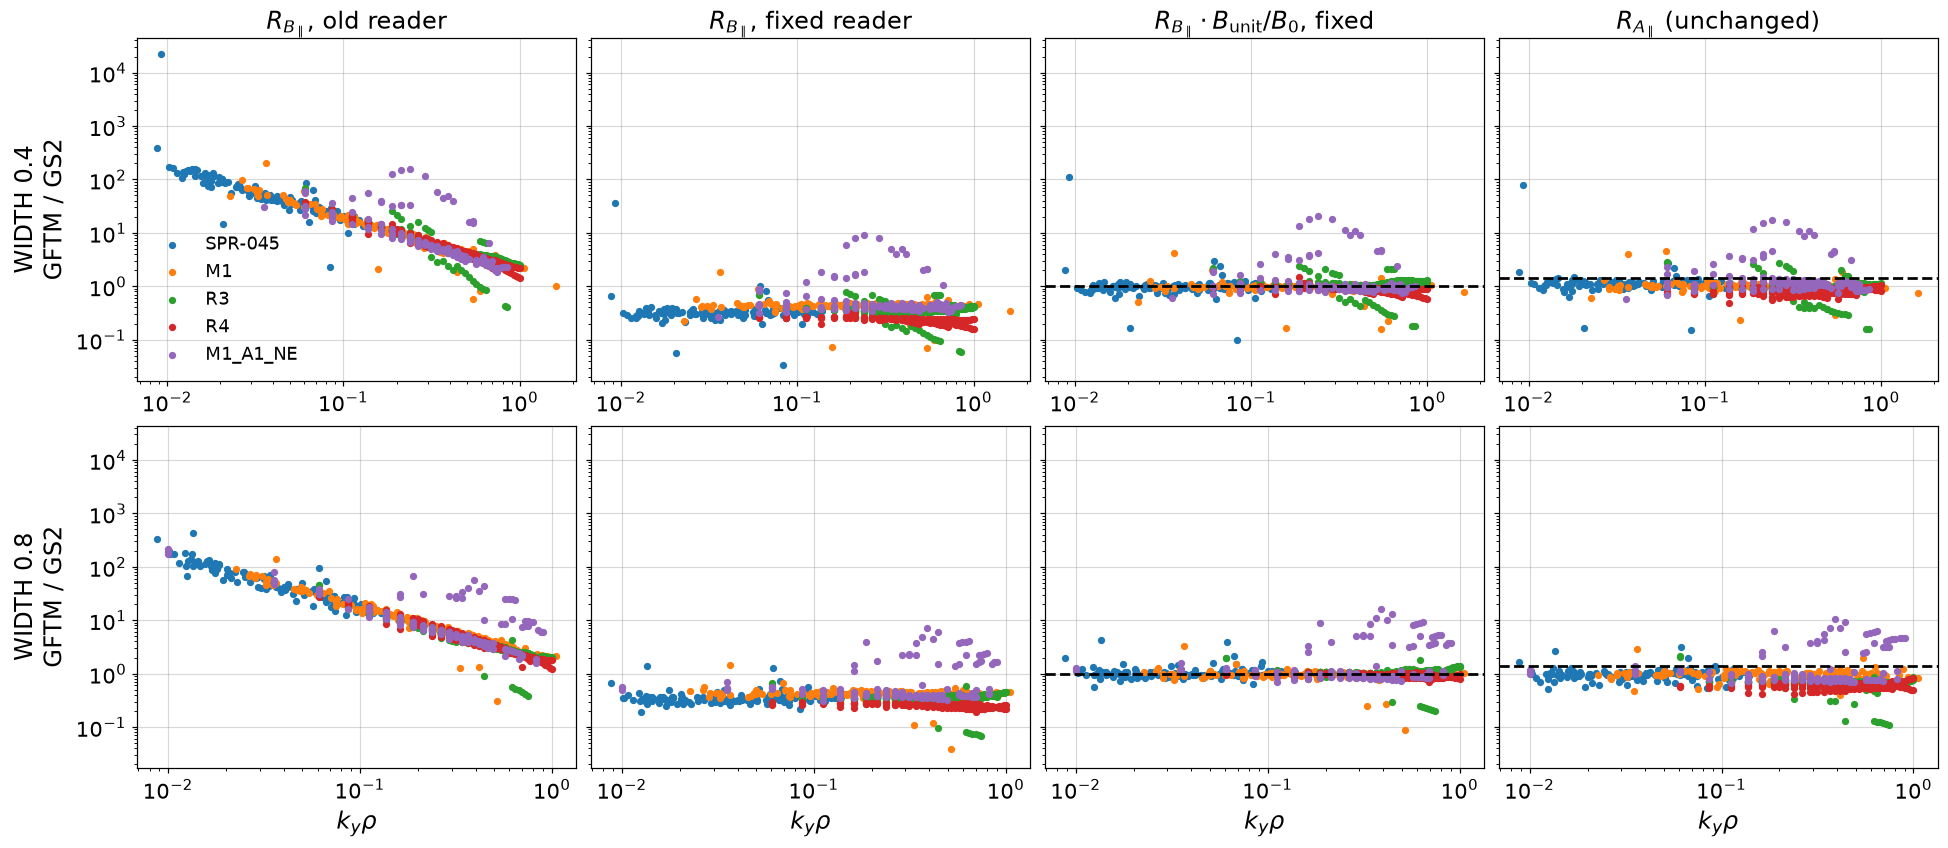

In [4]:
panels = [("RB_old", r"$R_{B_\parallel}$, old reader", None),
          ("RB_new", r"$R_{B_\parallel}$, fixed reader", None),
          ("RBn", r"$R_{B_\parallel}\cdot B_{\rm unit}/B_0$, fixed", 1.0),
          ("RA", r"$R_{A_\parallel}$ (unchanged)", np.sqrt(2))]
S = S.assign(RBn=S.RB_new / S.RB_pred)
fig, axes = plt.subplots(len(widths), len(panels), figsize=(4.4 * len(panels), 3.8 * len(widths)), sharey=True, squeeze=False)
for i, w in enumerate(widths):
    for j, (col, title, pred) in enumerate(panels):
        ax = axes[i, j]
        for k, db in enumerate(databases):
            df = S[(S.width == w) & (S.db == db)]
            ax.scatter(df.ky, df[col], s=14, color=f"C{k}", label=db)
        if pred is not None:
            ax.axhline(pred, color="k", ls="--", marker="none")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.tick_params(labelsize=fs_tick)
        if i == 0:
            ax.set_title(title, fontsize=fs_title)
        if i == len(widths) - 1:
            ax.set_xlabel(r"$k_y\rho$", fontsize=fs_label)
    axes[i, 0].set_ylabel(rf"WIDTH {w}" + "\n" + "GFTM / GS2", fontsize=fs_label)
axes[0, 0].legend(fontsize=fs_legend, loc="lower left")
fig.savefig(plot_dir / "fig1_before_after_R_vs_ky.png", dpi=150, bbox_inches="tight")
plt.show()
